# QELM vs QK

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import myQMLfunctions as myQML

In [2]:
rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)

In [3]:
print(rho_training.shape)
print(rho_training)
print('\n')
print(rho_training[0])

(100, 2, 2)
[[[ 0.86722127+0.00000000e+00j  0.02741181-4.50125498e-02j]
  [ 0.02741181+4.50125498e-02j  0.13277873+0.00000000e+00j]]

 [[ 0.41944064+0.00000000e+00j -0.0061367 -1.46407915e-01j]
  [-0.0061367 +1.46407915e-01j  0.58055936+0.00000000e+00j]]

 [[ 0.40499194+0.00000000e+00j  0.37776444-2.73707459e-01j]
  [ 0.37776444+2.73707459e-01j  0.59500806+0.00000000e+00j]]

 [[ 0.28114704+0.00000000e+00j -0.23475606-3.27772648e-01j]
  [-0.23475606+3.27772648e-01j  0.71885296+0.00000000e+00j]]

 [[ 0.52446334+0.00000000e+00j -0.08574802-8.51496862e-02j]
  [-0.08574802+8.51496862e-02j  0.47553666+0.00000000e+00j]]

 [[ 0.7117855 +0.00000000e+00j  0.18645779+4.72699252e-03j]
  [ 0.18645779-4.72699252e-03j  0.2882145 +0.00000000e+00j]]

 [[ 0.64908403+0.00000000e+00j  0.40067886+2.41694670e-01j]
  [ 0.40067886-2.41694670e-01j  0.35091597+0.00000000e+00j]]

 [[ 0.23969268+0.00000000e+00j -0.24095872-2.51229816e-01j]
  [-0.24095872+2.51229816e-01j  0.76030732+0.00000000e+00j]]

 [[ 0.684119

In [4]:
rho = myQML.generate_random_density_matrix(2)
print(rho)
print(np.trace(rho))

[[ 0.60816716+3.17847136e-18j -0.4132562 -1.03050271e-01j]
 [-0.4132562 +1.03050271e-01j  0.39183284-3.17847136e-18j]]
(1+0j)


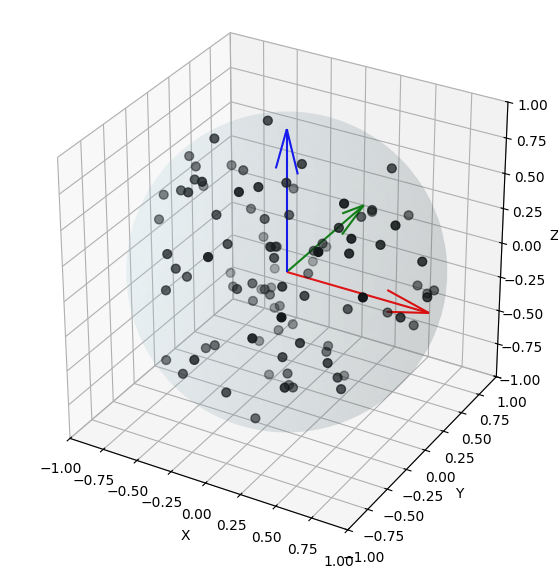

In [5]:
bloch_points_1 = [myQML.density_to_bloch(rho) for rho in rho_training]
myQML.plot_bloch_sphere(bloch_points_1)

In [8]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)

Predictions on test data (first 5):
[405.17087001   5.1717252  665.16290967 359.11804685 815.41533258]
Original test labels (first 5):
[-0.58596712  0.42369385 -0.50331429 -0.30196485 -0.26107665]
Mean Squared Error on training data: 241436.7287
Computing kernel matrix for 100 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(100,)

Predictions on training data (first 5):
[550.49086888 568.18410297 555.59654841 790.92098377 558.1752725 ]
Original training labels (first 5):
[ 0.05482362 -0.01227339  0.75552888 -0.46951212 -0.17149604]


In [10]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=1e-5)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)

Predictions on test data (first 5):
[-0.58596654  0.42369342 -0.50331382 -0.30196455 -0.26107644]
Original test labels (first 5):
[-0.58596712  0.42369385 -0.50331429 -0.30196485 -0.26107665]
Mean Squared Error on training data: 0.0000
Computing kernel matrix for 100 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(100,)

Predictions on training data (first 5):
[ 0.05482352 -0.01227341  0.75552809 -0.46951168 -0.1714959 ]
Original training labels (first 5):
[ 0.05482362 -0.01227339  0.75552888 -0.46951212 -0.17149604]


In [14]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
    kernelmodel.fit(rho_training, expe_training_X)
    predictions = kernelmodel.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)
Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)
Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complet

In [15]:
print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

Mean Squared Error across realizations: 5458.70495581621


In [ ]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel_le = myQML.QuantumKernelRegression2(regularization_lambda=1e-6, num_shots=1000)
    
    kernelmodel_le.fit(rho_training, expe_training_X, "le")
    predictions = kernelmodel_le.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

In [ ]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel_swap = myQML.QuantumKernelRegression2(regularization_lambda=1e-6, num_shots=1000)
    kernelmodel_swap.fit(rho_training, expe_training_X, "le")
    predictions = kernelmodel_le.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")